# Sugar Sugar study analysis — walkthrough

This notebook is a **thin UI over the library**. Every analysis step calls
`sugar_data_processing` the same way the CLI does. Reports are always written to
`output/reports/` (not a notebook-specific folder).

## Research question

How well can people predict **next-hour glucose** from recent CGM context,
and does accuracy differ by diabetes status, CGM use, experience, or own vs
generic data?

## Pipeline stages (library modules)

| Step | Stage | Module |
| --- | --- | --- |
| 1 | Gathering | `sugar_data_processing.gathering` |
| 2 | Verification | `sugar_data_processing.verification` |
| 3 | Statistics | `sugar_data_processing.statistics` |
| 4 | Comparison | `sugar_data_processing.comparison` |
| 5 | Output | `sugar_data_processing.output` → `output/reports/` |

**MAE** = mean absolute error (mg/dL). Lower is better.  
**Person-level MAE** = one score per participant (mean of their round MAEs).

Select the `sugar-data-processing (.venv)` kernel, then run cells top to bottom.

## 0. Setup (library session)

`prepare_session` configures the same default CSV and `output/` tree as the CLI.

In [1]:
from sugar_data_processing.runtime import prepare_session

session = prepare_session(globals())

import polars as pl

from sugar_data_processing import run_analysis
from sugar_data_processing.comparison import benchmark_context
from sugar_data_processing.gathering import (
    build_participant_table,
    load_prediction_statistics,
)
from sugar_data_processing.output import (
    explain_all_hypotheses,
    explain_benchmarks,
    explain_gathering,
    explain_report_written,
    explain_verification,
    show_report_figures,
    write_report,
)
from sugar_data_processing.statistics import hypotheses_table, run_all_hypotheses
from sugar_data_processing.verification import verify_dataset

CSV_PATH = session.csv_path
OUTPUT_DIR = session.output_dir

print("Library session ready.")
print(f"  Repository : {session.repo_root}")
print(f"  Input CSV  : {CSV_PATH}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Reports    : {session.reports_dir}")

Library session ready.
  Repository : C:\Users\liv\sources\sugar-sugar\sugar-data-processing
  Input CSV  : C:\Users\liv\sources\sugar-sugar\sugar-data-processing\data\fixtures\synthetic_prediction_statistics.csv
  Output dir : C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output
  Reports    : C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\reports


## Map of the hypotheses

Catalog comes from `sugar_data_processing.statistics.hypotheses_table()`.

In [2]:
hypotheses_table()

code,title,question,section
str,str,str,str
"""H1""","""Diabetes status and prediction…","""Do people with diabetes (PwD) …","""§7.3 primary"""
"""H2""","""CGM use and prediction accurac…","""Do continuous glucose monitor …","""§7.3 primary"""
"""H3""","""Diabetes duration and predicti…","""Among people with diabetes, is…","""§7.4 secondary"""
"""H4""","""CGM experience and prediction …","""Among CGM users, is longer CGM…","""§7.4 secondary"""
"""H5""","""Own data vs generic example da…","""Within the same person, is pre…","""§7.4 secondary"""
"""H6""","""Humans vs computational baseli…","""How does human next-hour MAE c…","""§7.4 deferred"""


## 1. Data gathering

Load the statistics export, expand rounds, and build **one row per participant**.

Library calls: `load_prediction_statistics`, `build_participant_table`, `explain_gathering`.

In [3]:
runs = load_prediction_statistics(CSV_PATH)
participants = build_participant_table(runs)

print(explain_gathering(runs, participants))
participants.select(
    "study_id",
    "diabetic",
    "uses_cgm",
    "mae_primary",
    "n_rounds_generic",
    "n_rounds_own",
    "eligible_primary",
    "eligible_h5",
).head(8)

### What just happened (data gathering)
1. Loaded each **run** (one completed app session) from the statistics CSV.
2. Expanded per-round prediction errors into tidy round rows.
3. Collapsed rounds into **one row per person** with a person-level MAE.
4. Marked who is eligible for primary analyses (≥6 generic rounds) and for the own-vs-generic paired test (≥6 generic and ≥6 own).

- Runs loaded: **210**
- Unique participants: **120**
- Eligible for primary analyses (H1–H4): **120**
- Eligible for own-data analyses: **90**
- Eligible for own-vs-generic paired test (H5): **90**
- Mean person MAE so far: **15.96 mg/dL**

Why person-level MAE? If one person plays many rounds, counting every round as an independent observation would overstate sample size. One summary score per person keeps the statistics honest.


study_id,diabetic,uses_cgm,mae_primary,n_rounds_generic,n_rounds_own,eligible_primary,eligible_h5
str,bool,bool,f64,i64,i64,bool,bool
"""01a0353e-186a-525b-aaec-0f3275…",false,true,18.089255,8,8,true,true
"""f4466555-7a85-5d0d-b107-55db0d…",true,true,9.728523,8,8,true,true
"""42691cfd-63d1-5e58-8457-4ae249…",false,true,17.589869,8,0,true,false
"""306f346c-3024-5166-8801-19d4c8…",true,true,4.436412,8,8,true,true
"""c8e1e418-1bce-5cbd-8f0c-8816ae…",false,true,10.473738,8,8,true,true
"""e17eb855-3d73-53c2-bf46-727c20…",true,true,7.500052,8,8,true,true
"""95b4ca26-959f-5c72-8641-233fab…",true,true,14.24482,8,8,true,true
"""4fd1ab98-1b33-539c-87bf-dd4921…",true,false,21.873223,8,8,true,true


## 2. Data verification

Schema checks first, then demographic / metric quality flags.

Library calls: `verify_dataset`, `explain_verification`.

In [4]:
verification = verify_dataset(runs, participants)
print(explain_verification(verification))

### What just happened (data verification)
Before trusting hypothesis tests, we check two layers:
1. **Schema / structural** — required columns, valid formats (A/B/C), parseable round metrics, non-empty IDs. High-severity failures mean the export is not trustworthy.
2. **Quality flags** — implausible ages/durations, flag mismatches, MAE outliers, short sessions. These do not always stop the analysis, but they should be reviewed.

- Schema checks: **passed**
- Schema issues: **0**
- Quality flags: **5** (3 high, 2 medium)

Examples (up to 5):
- [high] `diabetes_duration_gt_age` — diabetes_duration=21.91488714066286 > age=18.0 (study_id=74a0db49-97c6-54a7-8f8f-a3b96a91ad30)
- [high] `cgm_duration_gt_age` — cgm_duration_years=58.0 > age=53.0 (study_id=27ba2f05-f7cb-5c3f-b6f2-075df79abf2c)
- [high] `implausible_cgm_duration` — cgm_duration_years=58.0 (plausible ≤ 30.0) (study_id=27ba2f05-f7cb-5c3f-b6f2-075df79abf2c)
- [medium] `mae_iqr_outlier` — mae_primary=33.51 outside IQR fence [-0.53,

## 3. Statistical tests (H1–H5)

Run the study-design battery on person-level MAE.

Library calls: `run_all_hypotheses`, `explain_all_hypotheses`.

In [5]:
suite = run_all_hypotheses(participants)
print(explain_all_hypotheses(suite.to_dict()))
if suite.notes:
    print("Pipeline notes:")
    for note in suite.notes:
        print(f"  - {note}")

### What just happened (statistical tests)
We ran the study-design hypothesis battery on **person-level MAE**.
Primary tests compare groups; secondary tests look at experience correlations and own vs generic accuracy within the same person.

### Quick glossary (how to read the numbers)

| Term | Plain meaning |
| --- | --- |
| **MAE** | Mean absolute error (mg/dL). Average size of the prediction mistake. **Lower is better.** |
| **Person-level MAE** | One MAE per participant (mean of their round MAEs). Avoids counting the same person many times. |
| **p-value** | Chance of seeing a result at least this extreme if there were truly no effect. We call a result **significant** when p < 0.05. |
| **Significant** | Evidence is strong enough (at α = 0.05) to reject “no difference / no association”. Not the same as “large” or “clinically important”. |
| **Effect size** | How big the difference or association is (not only whether it is “significant”). |
| **t-test / Mann–Whitney** | Compare two

## 4. Literature / GlucoBench comparison

Place human MAE next to published 60-minute bands (context for H6, which is deferred).

Library calls: `benchmark_context`, `explain_benchmarks`.

In [6]:
eligible = participants.filter(pl.col("eligible_primary"))
bench_frame = eligible if eligible.height > 0 else participants
benchmarks = benchmark_context(bench_frame, mae_col="mae_primary")
print(explain_benchmarks(benchmarks))

### What just happened (literature comparison)
Human accuracy is placed next to published 60-minute prediction bands (simple/ARIMA, deep learning, personalized). This is **context**, not a formal H6 model comparison on the same segments.

Human mean MAE is 16.0 mg/dL (median 15.5, SD 8.9, n=120), which sits inside the published simple-baseline band. Reference 60-min bands — simple/ARIMA 12–20, deep learning 11–17, personalized 15–17 mg/dL (study design §7.5).

- People in simple/ARIMA band (12–20 mg/dL): **48.3%**
- People in deep-learning band (11–17 mg/dL): **39.2%**
- People better than the simple-band floor (<12 mg/dL): **29.2%**



## 5. Output — always `output/reports/`

Write the markdown report, figures, and interactive `study_explorer.html` to the **same** folder the CLI uses.

Library calls: `write_report`, `explain_report_written`, `show_report_figures`.

### What just happened (output)
Figures and a markdown report were written under the canonical `output/reports/` folder (same location for CLI and notebook).

- Report path: `C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\reports\study_analysis_report.md`
- PNG copies: `C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\reports\figures`


=== Overall distribution of per-person MAE ===
Spread of accuracy across people. Look for centre, spread, and outliers.


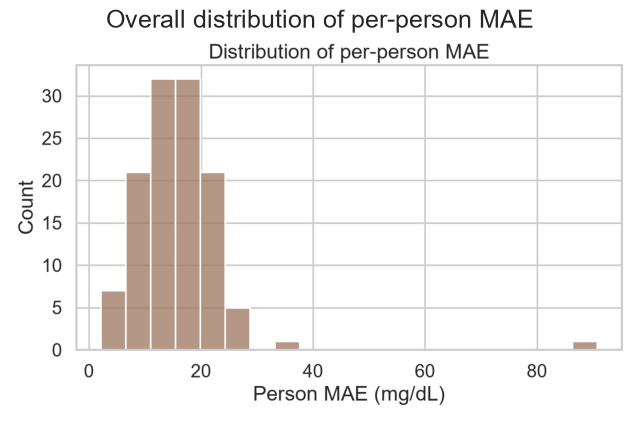


=== H1 - Diabetes status: PwD vs non-PwD ===
Lower boxes mean better accuracy. Compare the two groups visually.


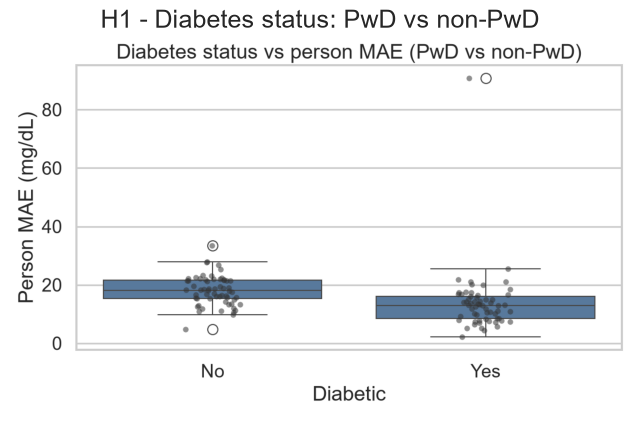


=== H2 - CGM use: users vs non-users ===
Same idea as H1, now split by CGM use.


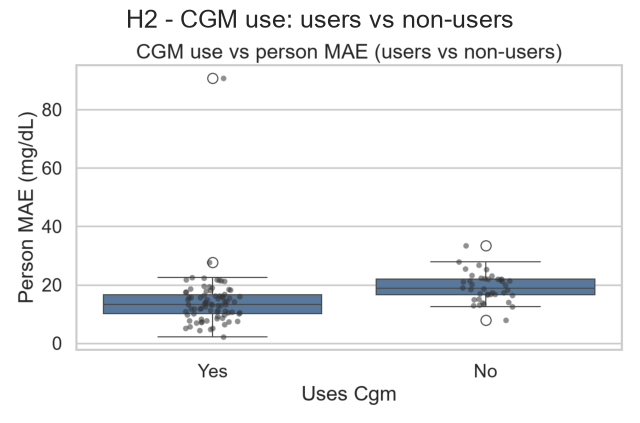


=== H3 - Diabetes duration vs MAE (PwD only) ===
A downward trend would mean longer duration associates with better accuracy.


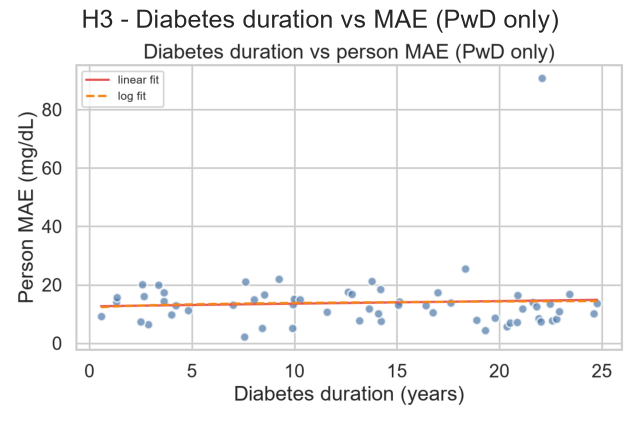


=== H4 - CGM experience vs MAE (CGM users) ===
A downward trend would mean more CGM experience associates with better accuracy.


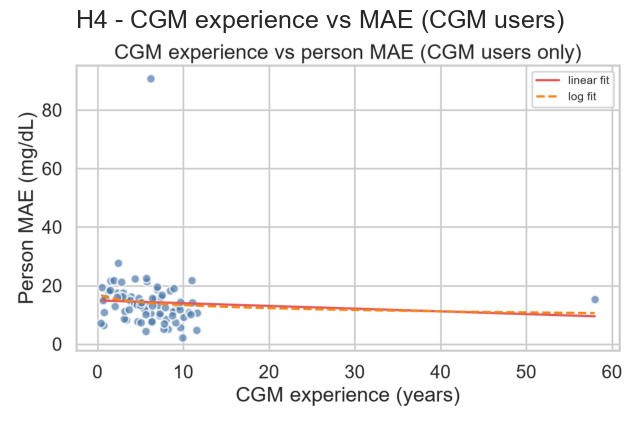


=== Exploratory duration / experience bins ===
Same story as the scatters, summarised in duration bins.


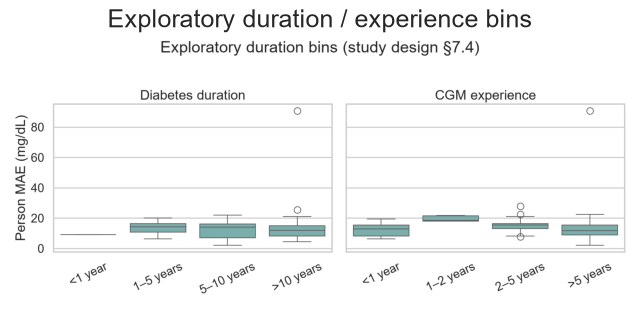


=== H5 - Own-data MAE vs generic-data MAE ===
Points below the diagonal: better on own data than on generic data.


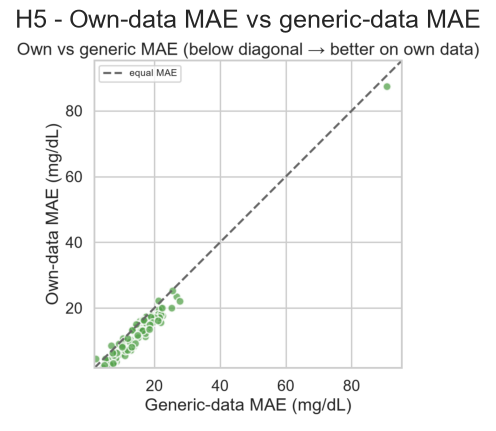


=== Human MAE vs published literature bands ===
Where the human distribution sits relative to published model bands.


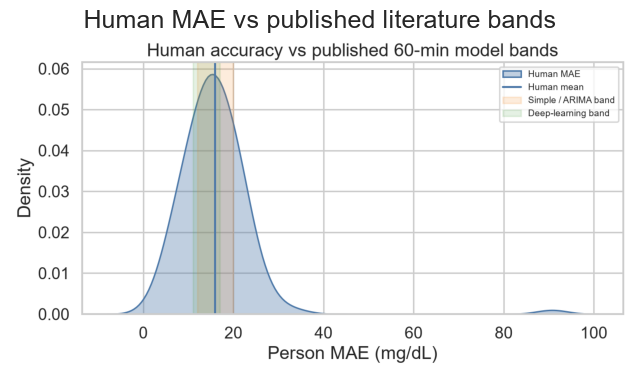

[WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/mae_distribution.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/h1_mae_by_diabetes.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/h2_mae_by_cgm.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/h3_diabetes_duration_scatter.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/h4_cgm_duration_scatter.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/h3_h4_duration_bins.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/h5_own_vs_generic.png'),
 WindowsPath('C:/Users/liv/sources/sugar-sugar/sugar-data-processing/output/reports/figures/benchmark_human_vs_literature.png')]

In [7]:
report_path = write_report(
    runs=runs,
    participants=participants,
    suite=suite,
    benchmarks=benchmarks,
    verification=verification,
    output_dir=OUTPUT_DIR,
    source_csv=CSV_PATH,
)
print(explain_report_written(report_path))
show_report_figures(OUTPUT_DIR)

## 6. One-shot library entry point

Same five stages via `run_analysis` — identical to
`uv run sugar-data-processing analyze --fixture`.

In [8]:
result = run_analysis(CSV_PATH, OUTPUT_DIR)
print("One-shot pipeline finished.")
print(f"  Report              : {result.report_path}")
print(f"  Verification passed : {result.verification.passed}")
print(f"  Mean person MAE     : {result.benchmarks.human_mean_mae:.2f} mg/dL")
print("\nReadable deliverable: output/reports/study_analysis_report.md")
print("Interactive explorer : output/reports/study_explorer.html")

One-shot pipeline finished.
  Report              : C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\reports\study_analysis_report.md
  Verification passed : True
  Mean person MAE     : 15.96 mg/dL

Readable deliverable: output/reports/study_analysis_report.md
